# Loan Data Classification


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



In [4]:
# Load the dataset
df = pd.read_csv("loan_data.csv")
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
# Display information about the dataset 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
# Check for missing values
md = df.isnull().sum()
md


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
# Summary statistics for numerical columns
df.describe()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


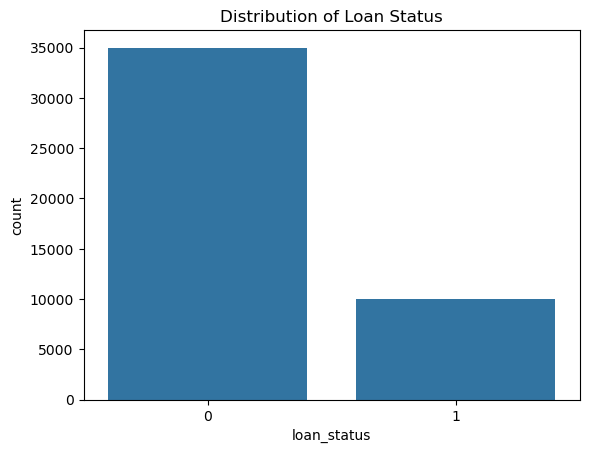

In [10]:
# Target variable distribution
sns.countplot(data=df, x="loan_status")
plt.title("Distribution of Loan Status")
plt.show()


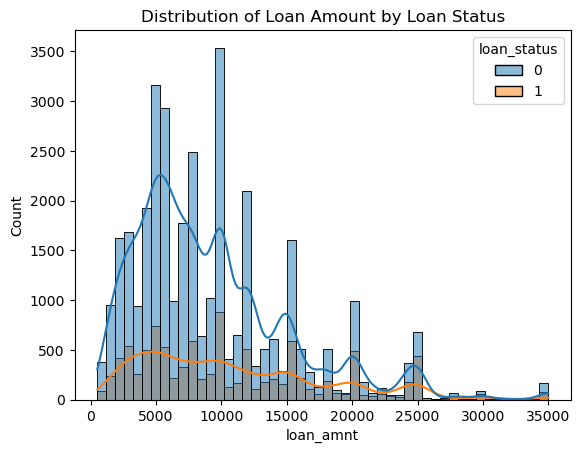

In [12]:
# Distribution of loan amounts by status
sns.histplot(data=df, x="loan_amnt",hue="loan_status", bins=50, kde=True)
plt.title("Distribution of Loan Amount by Loan Status")
plt.show()


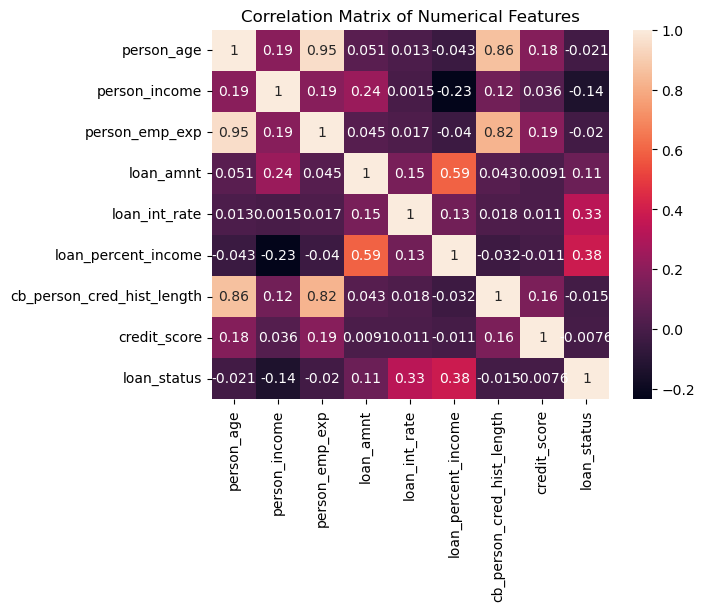

In [22]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


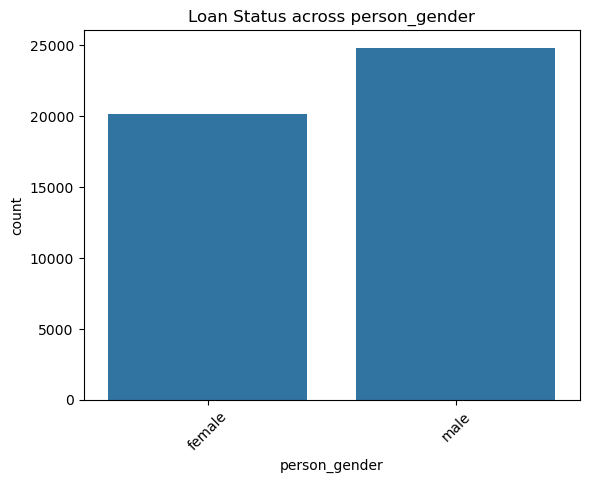

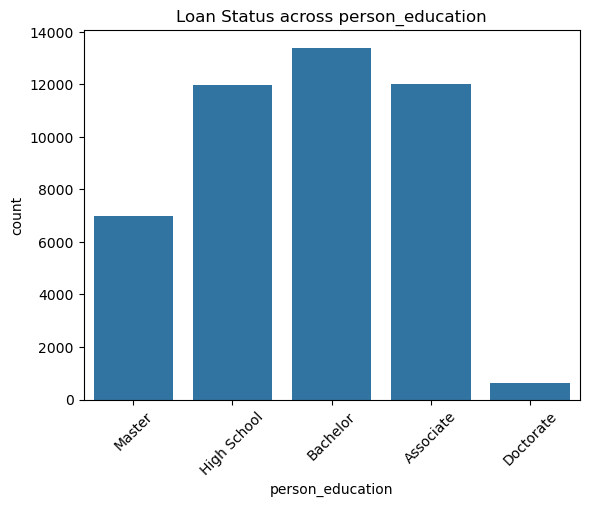

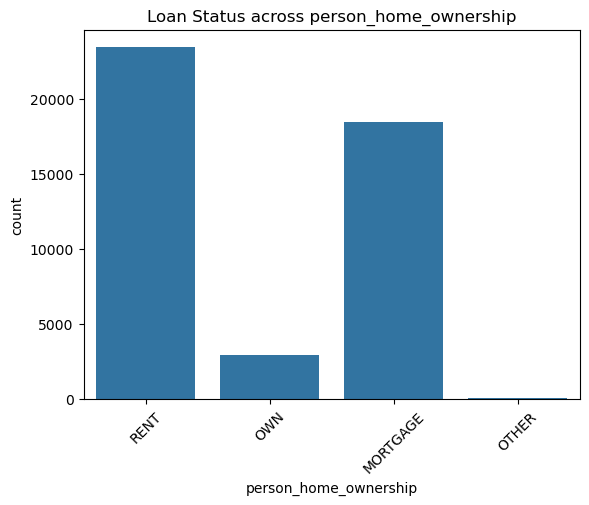

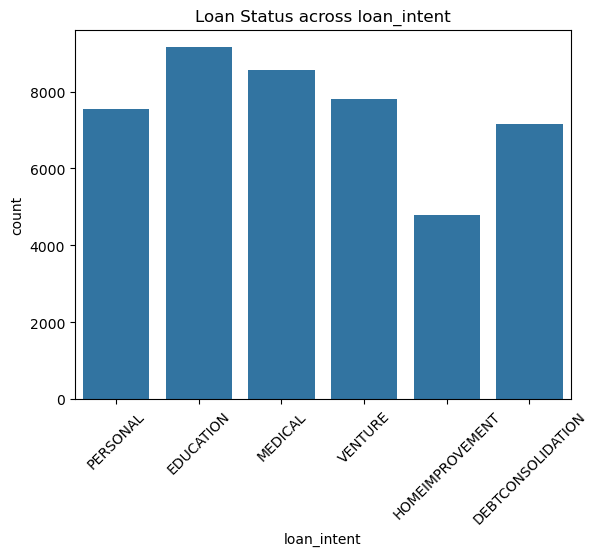

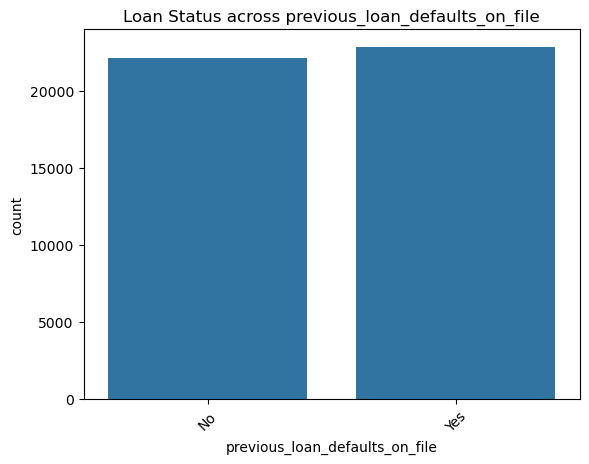

In [30]:
# Categorical variables vs Loan Status
categorical_cols = df[["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]]

for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Loan Status across {col}")
    plt.show()


In [37]:
# Separate features (X) and target (y)
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(numeric_features)
categorical_features


['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


['person_gender',
 'person_education',
 'person_home_ownership',
 'loan_intent',
 'previous_loan_defaults_on_file']

In [60]:
# Create pre-processing pipelines for both numeric and categorical data

# For numeric data
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)
# Fit and transform only the numeric features
X_numeric_transformed = numeric_transformer.fit_transform(df[numeric_features])
X_numeric_transformed

array([[-0.95353824, -0.10408961, -0.89228413, ...,  4.01639414,
        -0.73910854, -1.41981408],
       [-1.11896309, -0.84600467, -0.89228413, ..., -0.6848294 ,
        -0.99686317, -2.5499748 ],
       [-0.45726369, -0.84406489, -0.3975175 , ...,  3.4430742 ,
        -0.73910854,  0.04741211],
       ...,
       [ 0.8661351 , -0.29068126,  0.26217134, ..., -1.02882137,
         1.06517387,  0.70171569],
       [ 0.2044357 , -0.58634807, -0.23259529, ...,  2.52576229,
         0.03415535, -0.5672367 ],
       [-0.62268854, -0.35699428, -0.72736192, ..., -0.11150946,
        -0.73910854, -0.09137955]], shape=(45000, 8))

In [61]:
# For categorical data: Impute missing values with the most frequent value, then apply OneHotEncoder
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="first")
)
X_categoric_transformed = categorical_transformer.fit_transform(df[categorical_features])
X_categoric_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 145037 stored elements and shape (45000, 14)>

### Model Building 
split the data into training (70%) and testing (30%) sets


In [67]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)
print(X_test.shape)


(31500, 13)
(13500, 13)


In [69]:
# Define the model pipeline
model = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
)

# Train the model
print("Training the Gradient Boosting model. This may take a few moments...")
model.fit(X_train, y_train)
print("Model training complete.")


Training the Gradient Boosting model. This may take a few moments...
Model training complete.


In [70]:
# to make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Display evaluation metrics
print("Accuracy:  {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall:    {:.4f}".format(recall_score(y_test, y_pred)))
print("F1 Score:  {:.4f}".format(f1_score(y_test, y_pred)))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy:  0.9224
Precision: 0.8692
Recall:    0.7669
F1 Score:  0.8148

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     10493
           1       0.87      0.77      0.81      3007

    accuracy                           0.92     13500
   macro avg       0.90      0.87      0.88     13500
weighted avg       0.92      0.92      0.92     13500



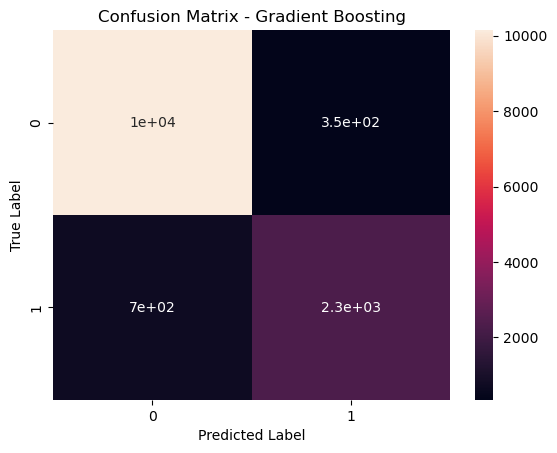

In [75]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
